# CODE D'EXPLOITATION DE DATASET POUR OBTENIR DES GRANDEURS DERIVÉES : Cas de la géostrophie

## Importation de bibliothèques

In [7]:

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['American Typewriter']
plt.rcParams.update({'font.size': 14}) # Taille de base pour tout

## Définition des constantes

In [8]:
f = 1.e-04                    # s-1 valeur approchée de la fréquence d'inertie
g = 9.81                      # m/s
rayon_terre = 6371000         # m
pi = np.pi                    # 3.14159...

T_inertie = 2*pi/f/3600       # calcul de la periode d'inertie en h

## Création et visualisation du Dataset

In [9]:
ds = xr.open_dataset('/Users/arnoldkono/Desktop/zelin/sat.nc')
ds = ds.sel(latitude=slice(34.5,45.,None)).sel(longitude=slice(-5.,17.,None)).squeeze(dim='time')
ds

<xarray.Dataset> Size: 831kB
Dimensions:    (latitude: 84, nv: 2, longitude: 176)
Coordinates:
    time       datetime64[ns] 8B 2017-11-21
  * latitude   (latitude) float32 336B 34.56 34.69 34.81 ... 44.69 44.81 44.94
  * longitude  (longitude) float32 704B -4.938 -4.812 -4.688 ... 16.81 16.94
  * nv         (nv) int32 8B 0 1
Data variables:
    crs        int32 4B ...
    lat_bnds   (latitude, nv) float32 672B ...
    lon_bnds   (longitude, nv) float32 1kB ...
    ugosa      (latitude, longitude) float64 118kB ...
    ssh        (latitude, longitude) float64 118kB ...
    ugos       (latitude, longitude) float64 118kB ...
    sla        (latitude, longitude) float64 118kB ...
    vgos       (latitude, longitude) float64 118kB ...
    vgosa      (latitude, longitude) float64 118kB ...
    err        (latitude, longitude) float64 118kB ...
Attributes: (12/44)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    time_coverage_duration:          P1D
    time_coverage_end:               2017-11-21T00:00:00Z
    time_coverage_resolution:        P1D
    time_coverage_start:             2017-11-21T00:00:00Z
    title:                           NRT merged all satellites Mediterranean ...
    NCO:                             "4.6.4"

## Visualisation du niveau de la mer pour un pas de temps précis

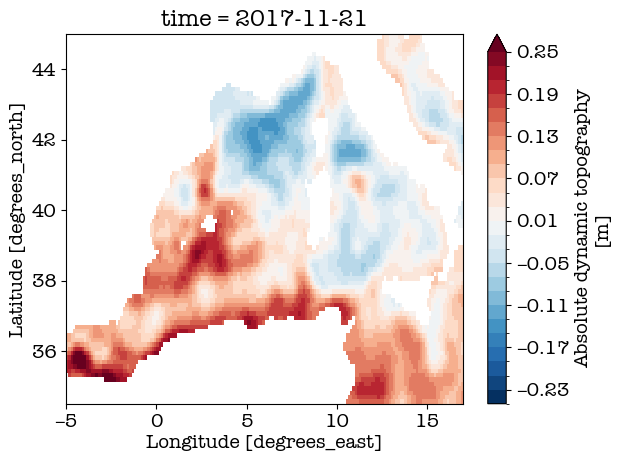

In [10]:
ds.ssh.plot(levels=np.arange(-.25,.26,.02))

## Extraction des caractéristiques et calcul des courants géostrophiques

Text(0.5, 1.0, 'Courants Geostrophiques calculés')

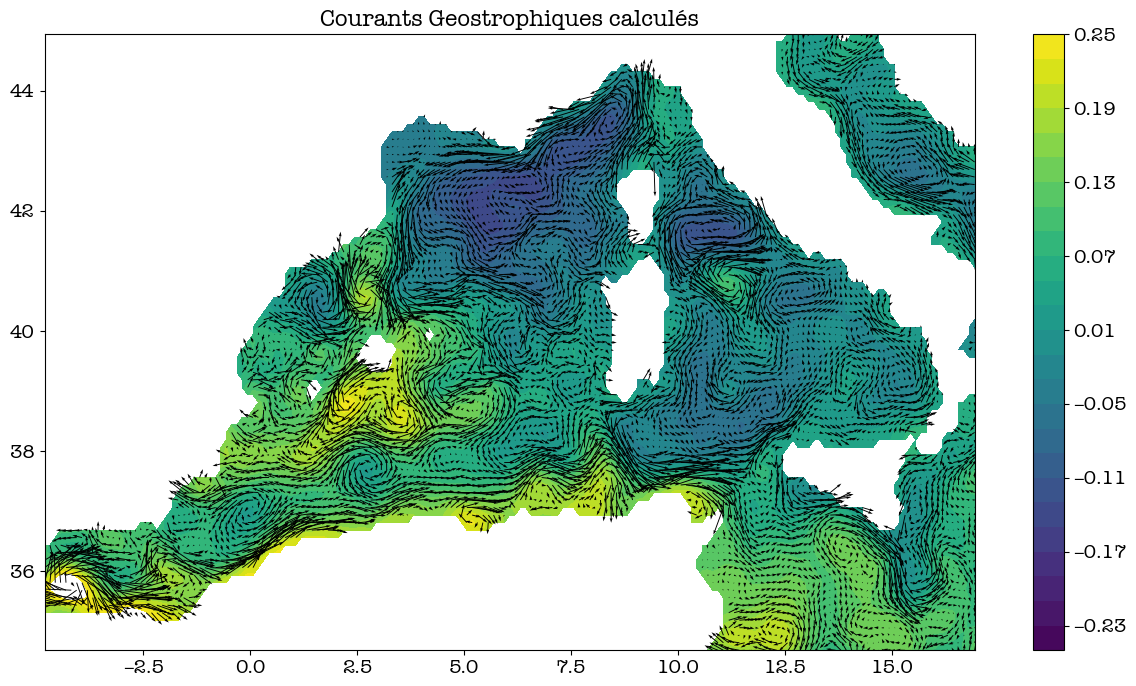

In [ ]:
#On extrait les caractéristiques
SSH = ds.ssh.values         # Niveau de la mer
LAT = ds.latitude.values        # Latitude
LON = ds.longitude.values       # Longitude

#On Calcule les dérivées
dlat = (LAT[1:]-LAT[:-1])           # Dériée de la Latitude
dy =  (rayon_terre * dlat * pi/180.).mean()   # Conversion en coordonnées cartésiennes      
dlon = (LON[1:]-LON[:-1])           # Dériée de la Longitude
dx =  (np.cos(pi*LAT.mean()/180.) * rayon_terre * dlon * pi/180.).mean()         # Conversion en coordonnées cartésiennes 

#On Calcule les vitesses géostrophiques
U = -(g/f)*(SSH[1:,:]-SSH[:-1,:])/dy
V = (g/f)*(SSH[:,1:]-SSH[:,:-1])/dx
LON,LAT = np.meshgrid(LON[1:],LAT[1:])

#Affichage des valeurs de courants géostrophiques  calculées
plt.figure(figsize=(15,8))
plt.contourf(LON,LAT,SSH[1:,1:],levels=np.arange(-.25,.26,.02))
plt.colorbar()
plt.quiver(LON,LAT,U[:,1:],V[1:,:],scale=10,width=.001)
plt.title('Courants Geostrophiques calculés')

Text(0.5, 1.0, 'Courant géostrophique Copernicius')

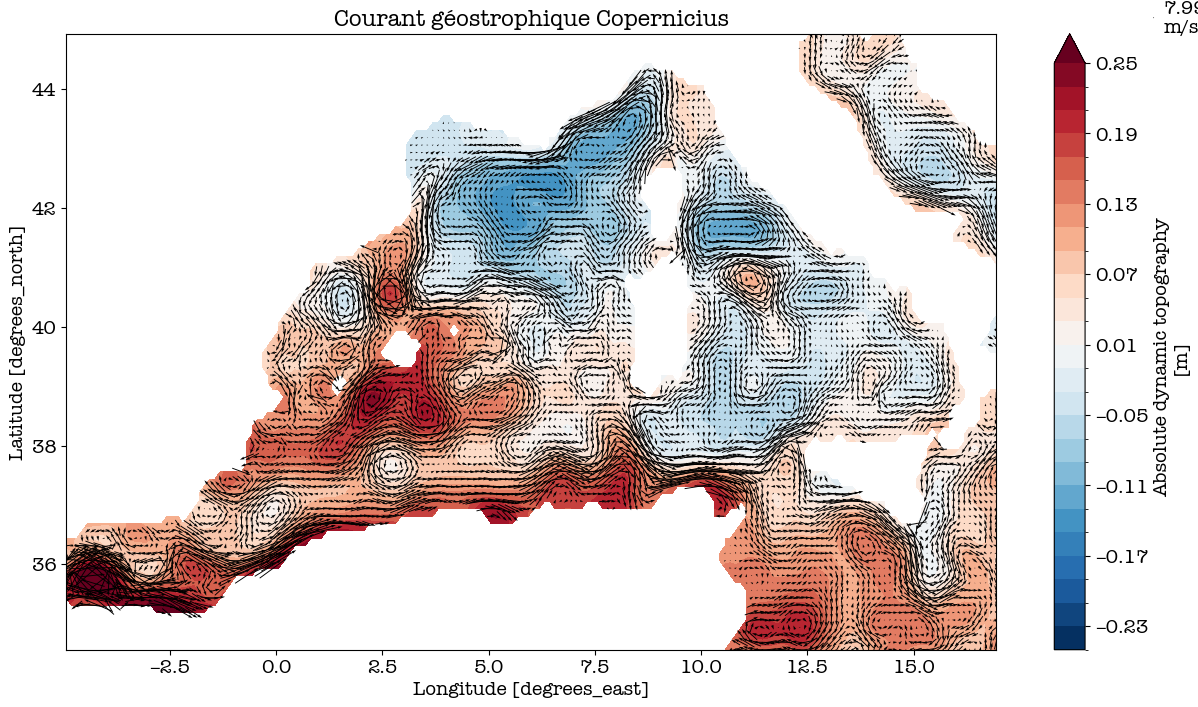

In [12]:
#Affichage des valeurs de courants géostrophiques fournies par copernicius
plt.figure(figsize=(15,8))
ds.ssh.plot.contourf(levels=np.arange(-.25,.26,.02))
ds.plot.quiver(x='longitude',y='latitude',u='ugos',v='vgos',scale=10,width=.001)
plt.title('Courant géostrophique Copernicius')